# Exercise 2: Flow Matching
Exercise by [Jes Frellsen](https://frellsen.org) (Technical University of Denmark), March 2026 (version 1.0).

In this programming exercise, you will implement **Flow Matching** using the conditional optimal transport (linear) path as introduced by [Lipman et al., 2023](https://arxiv.org/abs/2210.02747) and further discussed/reviewed by [Lipman et al., 2024](https://arxiv.org/abs/2412.06264) and as well as in Chapter 9.4 of Tomczak's [Deep Generative Modeling](https://link.springer.com/book/10.1007/978-3-031-64087-2) book. 

You will experiment with both **toy datasets** and the **MNIST dataset**. The toy datasets are generated using the code provided in `ToyData.py`. For MNIST, pixel values are rescaled to the interval $[-1,1]$, and the toy datasets are scaled to the same range.

The provided code contains a **skeleton implementation** of the training and sampling procedures. Your task is to complete the missing components according to the instructions given **in the exercise section following the code**.

Two files are provided as part of the exercise.
* `unet.py` contains the implementation of a **U-Net architecture** that predicts the velocity field $v_t(x)$ for **MNIST**. The implementation of the U-Net is adapted from
[Muhammad Firmansyah Kasim](https://github.com/mfkasim1/score-based-tutorial/blob/main/03-SGM-with-SDE-MNIST.ipynb).
* `ToyData.py` contains code for generating simple **two-dimensional toy datasets**.

You can download the files using the following commands:

In [1]:
! curl -O https://raw.githubusercontent.com/frellsen/GeMSS-2026/refs/heads/main/unet.py
! curl -O https://raw.githubusercontent.com/frellsen/GeMSS-2026/refs/heads/main/ToyData.py

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  5563  100  5563    0     0  34765      0 --:--:-- --:--:-- --:--:-- 34987
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  3762  100  3762    0     0  23262      0 --:--:-- --:--:-- --:--:-- 23366


# Implementing the Flow model
**Implementation:** Below we provide skeleton implementation of a Flow model. The code is missing the implementation of the loss, sample function and the likelihood calcuation. Your task will be to complete them (see Exercise 1 below).

In [2]:
import torch
import torch.nn as nn
import torch.distributions as td
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import numpy as np

import ToyData

In [3]:
class Flow(nn.Module):
    def __init__(self, network):
        """
        Initialize the Flow model.

        Parameters:
        network: [nn.Module]
            The network to use for velocity field.
        sigma_min: [float]
            The noise at the first step of the diffusion process.
        """
        super(Flow, self).__init__()
        self.network = network

    def x_t(self, x_0, x_1, t):
        """
        Calculate the linear interpolation between x_0 and x_1

        Parameters:
        x_0: [torch.Tensor]
            A sample from the source distribution of dimension `(batch_size, *)`.
        x_1: [torch.Tensor]
            A sample from the target distrubiton (data) of dimension `(batch_size, *)`.
        t: [torch.Tensor]
            The time steps `(batch_size, 1)`.
        Returns:
        [torch.Tensor]
            A sample from conditional probability path at time t of dimension `(batch_size, *)`.
        """
        return (1 - t) * x_0 + t * x_1


    def loss(self, x_1):
        """
        Evaluate the loss on a batch of data.

        Parameters:
        x_1: [torch.Tensor]
            A batch of data (x), i.e., samples from the target distribution, of dimension `(batch_size, *)`.
        Returns:
        [torch.Tensor]
            The conditional Flow Matching loss `(1,)`.
        """

        # Sample the time steps and reshape to (batch_size, 1, 1, ..., 1) for broadcasting
        t = td.uniform.Uniform(0, 1).sample((x_1.shape[0],) + (x_1.dim()-1)*(1,)).to(x_1.device)

        # Sample x_0 from p_0
        x_0 = torch.randn_like(x_1)

        # Calculate the value(s) of the conditional flow at time t
        x_t = self.x_t(x_0, x_1, t)

        # Calculate the loss
        target = x_1 - x_0
        v_t = self.network(x_t, t.view(-1, 1) if t.dim() > 1 else t)
        loss = torch.mean((v_t - target) ** 2)

        return loss


    def sample(self, shape, T):
        """
        Sample from the model.

        Parameters:
        shape: [tuple]
            The shape of the samples to generate.
        T: [int]
            The number of steps in the Euler discretization
        Returns:
        [torch.Tensor]
            The generated samples.
        """

        device = next(self.network.parameters()).device

        # Set the time step size
        delta_t = 1.0/T

        # Sample x_0 from p_0
        x_0 = torch.randn(shape).to(device)

        # Under the assumption of a linear interpolation between x_0 and x_1, the value of the conditional flow at time t=0 is just x_0
        x_t = x_0

        # Sample calculate pht_t given the phi_{t-1}
        for i in range(1, T+1):
            # Current time step
            t = (i - 1) * delta_t

            # Calculate the value of the velocity field at time t
            t = torch.full((x_0.shape[0],1), t).to(device)
            v_t = self.network(x_t, t)

            # Do one Euler step to x_t using the velocity field
            x_t = x_t + delta_t * v_t

        return x_t

**Training loop**: We have also implemented a generic training loop for learning the Flow model.

In [4]:
def train(model, optimizer, data_loader, epochs, device):
    """
    Train a Flow model.

    Parameters:
    model: [Flow]
       The model to train.
    optimizer: [torch.optim.Optimizer]
         The optimizer to use for training.
    data_loader: [torch.utils.data.DataLoader]
            The data loader to use for training.
    epochs: [int]
        Number of epochs to train for.
    device: [torch.device]
        The device to use for training.
    """
    model.train()

    total_steps = len(data_loader)*epochs
    progress_bar = tqdm(range(total_steps), desc="Training")

    for epoch in range(epochs):
        data_iter = iter(data_loader)
        for x in data_iter:
            if isinstance(x, (list, tuple)):
                x = x[0]
            x = x.to(device)
            optimizer.zero_grad()
            loss = model.loss(x)
            loss.backward()
            optimizer.step()

            # Update progress bar
            progress_bar.set_postfix(loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
            progress_bar.update()

**Training data**: Next, we load the toy training data and transformed to the interval $[-1,1]$.

In [5]:
# Generate the data choosing between two toy datasets (0: Two Gaussians, 1: Chequerboard)
toy_dataset_number = 0
n_data = 10000000
toy = {0: ToyData.TwoGaussians, 1: ToyData.Chequerboard}[toy_dataset_number]()

# Transform the data to be in the range [-1, 1] and create data loaders
transform = lambda x: (x-0.5)*2.0
train_loader = torch.utils.data.DataLoader(transform(toy().sample((n_data,))), batch_size=10000, shuffle=True)
test_loader = torch.utils.data.DataLoader(transform(toy().sample((n_data,))), batch_size=10000, shuffle=True)

# Get the dimension of the dataset
D = next(iter(train_loader)).shape[1]

We also plot the training data.

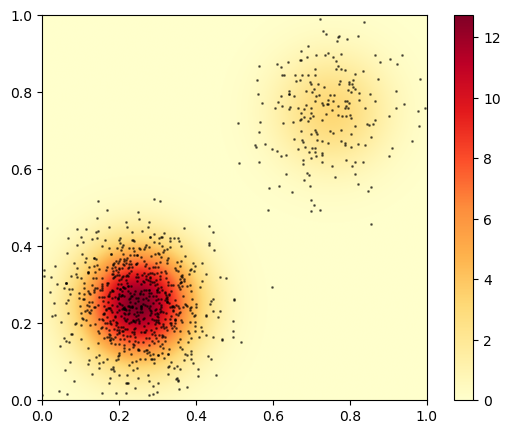

In [6]:
def plot_toy_data(toy, samples):
    """Plot the toy data and the samples from the model."""
    coordinates = [[[x,y] for x in np.linspace(*toy.xlim, 1000)] for y in np.linspace(*toy.ylim, 1000)]
    prob = torch.exp(toy().log_prob(torch.tensor(coordinates)))

    fig, ax = plt.subplots(1, 1, figsize=(7, 5))
    im = ax.imshow(prob, extent=[toy.xlim[0], toy.xlim[1], toy.ylim[0], toy.ylim[1]], origin='lower', cmap='YlOrRd')
    ax.scatter(samples[:, 0], samples[:, 1], s=1, c='black', alpha=0.5)
    ax.set_xlim(toy.xlim)
    ax.set_ylim(toy.ylim)
    ax.set_aspect('equal')
    fig.colorbar(im)
    plt.show()

# Take 1000 samples from the toy dataset and plot them
samples = toy().sample((1000,)).numpy()
plot_toy_data(toy, samples)


**Initialize the model and run the training loop**:

We define a small fully connected network to use as the velocity field for the Flow model. The network takes as input a sample from the conditional flow at time $t$ and the time step $t$, and outputs a vector of the same dimension as the data.

In [7]:
class FcNetwork(nn.Module):
    def __init__(self, input_dim, num_hidden):
        """
        Initialize a fully connected network for the velocity field in the Flow model, where the forward function also take time as an argument.
        
        parameters:
        input_dim: [int]
            The dimension of the input data.
        num_hidden: [int]
            The number of hidden units in the network.
        """
        super(FcNetwork, self).__init__()
        self.network = nn.Sequential(nn.Linear(input_dim+1, num_hidden), nn.ReLU(), 
                                     nn.Linear(num_hidden, num_hidden), nn.ReLU(), 
                                     nn.Linear(num_hidden, input_dim))

    def forward(self, x, t):
        """"
        Forward function for the network.
        
        parameters:
        x: [torch.Tensor]
            The input data of dimension `(batch_size, input_dim)`
        t: [torch.Tensor]
            The time of dimension `(batch_size, 1)`
        """
        x_t_cat = torch.cat([x, t], dim=1)
        return self.network(x_t_cat)

Finally, we initialize the model and run the training loop. Remember that this will not work before you have completed the assignment below.

In [8]:
# Define the network
num_hidden = 64
network = FcNetwork(D, num_hidden)

# Define model
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")
model = Flow(network).to(device)

# Define optimizer
lr = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# Train model
epochs = 1
train(model, optimizer, train_loader, epochs, device)

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

**Sampling**: Then we sample from the model and compare it to the ground truth density.

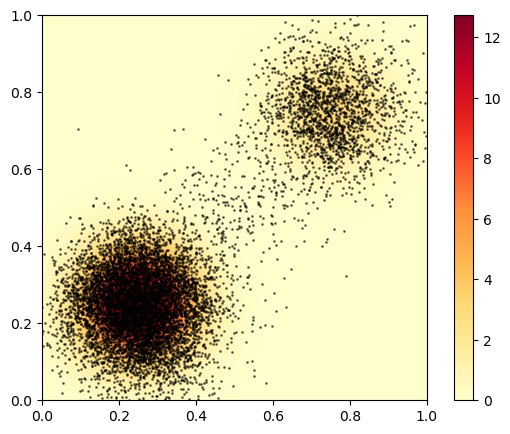

In [9]:
with torch.no_grad():
    samples = (model.sample((10000, D), T=100)).cpu()

# Transform the samples back to the original space
samples = samples /2 + 0.5

plot_toy_data(toy, samples.numpy())

# Exercise 2.1

Complete the Flow implementation above by filling in the following components:

* `Flow.loss(...)` should implement the conditional Flow Matching loss for the optimal transport (linear) path

  $$
  \mathcal{L}_{\textrm{CFM}}(\theta)
  = \mathbb{E}_{t,x_0,x_1}\|v^{\theta}(x_t, t) - (x_1 - x_0)\|^2
  $$

  where $t \sim U[0,1]$, $x_0 \sim p_0$, $x_1 \sim p_1$ and $x_t = (1-t)x_0 + tx_1$.

* `Flow.sample(...)` should implement sampling using an ODE Euler solver.

The locations where code should be added are marked with `# ADD YOUR CODE HERE`.

# Exercise 2.2
Once you have implemented the Flow model and verified it on the toy datasets, train it on the MNIST dataset using the provided U-Net architecture. The code below provides utilities for loading the data and visualising the results.

**Training data**: We load the MNIST training set and transform the pixels to the interval $[-1,1]$. **For faster training, we initially only load the first 64 images from the traininset.** You may want to change this.

In [10]:
from torchvision import datasets, transforms

batch_size = 64

# Define the transform to use for the data
transform=transforms.Compose([transforms.ToTensor(),
                                transforms.Lambda(lambda x: x + torch.rand(x.shape)/255),
                                transforms.Lambda(lambda x: (x-0.5)*2.0),
                                transforms.Lambda(lambda x: x.flatten())])

# Load the data
train_data = datasets.MNIST('data/', train=True, download=True, transform=transform)

# Load only the first 64 samples for training
train_data = torch.utils.data.Subset(train_data, range(batch_size))

# Create the data loaders
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)

# Get the dimension of the dataset
D = next(iter(train_loader))[0].shape[1]

**Initialize the model and run the training loop**: We initializes the model and run the training loop. Again, this will not work before you have completed the assignment below.

In [11]:
# Define the network
from unet import Unet
network = Unet()

# Define model
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")
model = Flow(network).to(device)

# Define optimizer
lr = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# Train model
epochs = 2000
train(model, optimizer, train_loader, epochs, device)

Training:   0%|          | 0/2000 [00:00<?, ?it/s]

**Sampling**: The following code samples from a trained model and plots the samples for MNIST.

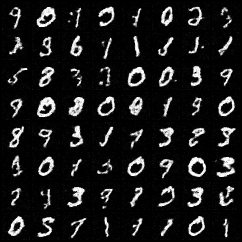

In [12]:
from torchvision.transforms.functional import to_pil_image
from torchvision.utils import make_grid
from IPython.display import display

# Generate samples
model.eval()
with torch.no_grad():
    samples = (model.sample((64,D), T=1000)).cpu() 
    samples = (samples /2 + 0.5).clamp(0, 1)

image_pil = to_pil_image(make_grid(samples.view(64, 1, 28, 28)))
display(image_pil)